# Clinical Readmission Analytics

## Clinical Insights and Summary

This notebook translates exploratory and statistical findings into clinically meaningful insights about hospital readmission patterns among diabetic patients.

In [1]:
import pandas as pd
import numpy as np

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading the cleaned dataset

df = pd.read_csv("../data/cleaned_diabetes_readmission.csv")

df.shape

(101766, 45)

In [3]:
# recreate the statistical results 

df["readmitted_binary"] = np.where(df["readmitted"] == "NO", "Not Readmitted", "Readmitted")

## Executive Summary

This analysis suggests that readmission is associated with several healthcare utilization patterns, especially length of stay and prior inpatient visits. 

Medication burden also appears clinically relevant. Demographic associations were explored, but the strongest signals came from utilization-related variables.

### Clinical Question 1: Who is most at risk?

In [4]:
summary_by_readmission = df.groupby("readmitted_binary")[[
    "time_in_hospital",
    "num_medications",
    "number_inpatient",
    "number_emergency",
    "number_outpatient"
]].median()

summary_by_readmission

,time_in_hospital,num_medications,number_inpatient,number_emergency,number_outpatient
readmitted_binary,,,,,
Not Readmitted,3.0,14.0,0.0,0.0,0.0
Readmitted,4.0,15.0,0.0,0.0,0.0


## Insight 1: Utilization patterns differ by readmission status

Patients who were readmitted tend to show higher prior inpatient use and different hospital utilization patterns, suggesting greater clinical complexity.

### Clinical question 2: Does length of stay matter?

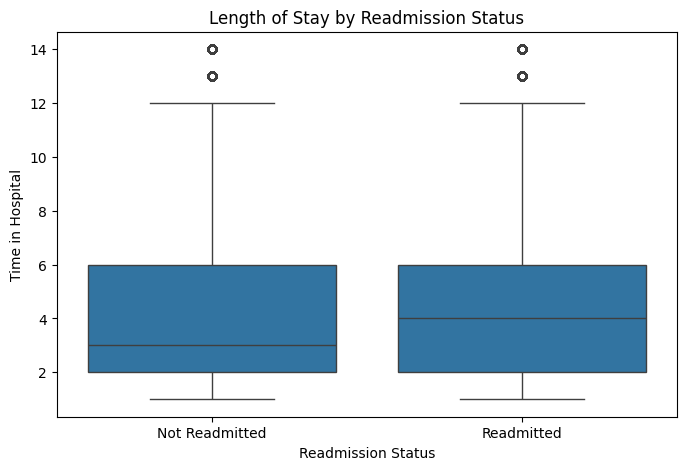

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="readmitted_binary", y="time_in_hospital")
plt.title("Length of Stay by Readmission Status")
plt.xlabel("Readmission Status")
plt.ylabel("Time in Hospital")
plt.show()

## Insight 2: Length of stay may reflect illness severity

Longer hospital stays may indicate more severe or complex cases, which aligns with higher readmission risk in some patients.

### Clinical question 3: Does medication burden matter?

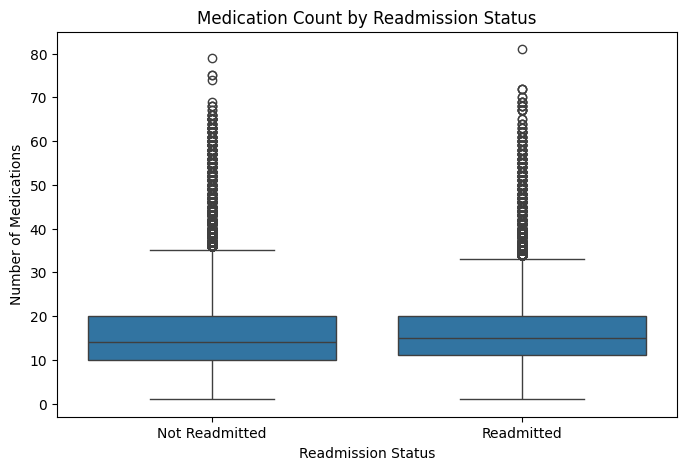

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="readmitted_binary", y="num_medications")
plt.title("Medication Count by Readmission Status")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Medications")
plt.show()

## Insight 3: Medication burden may signal clinical complexity

Patients with more medications may be managing multiple conditions, which can complicate discharge planning and follow-up care.

### Clinical question 4: Prior inpatient history

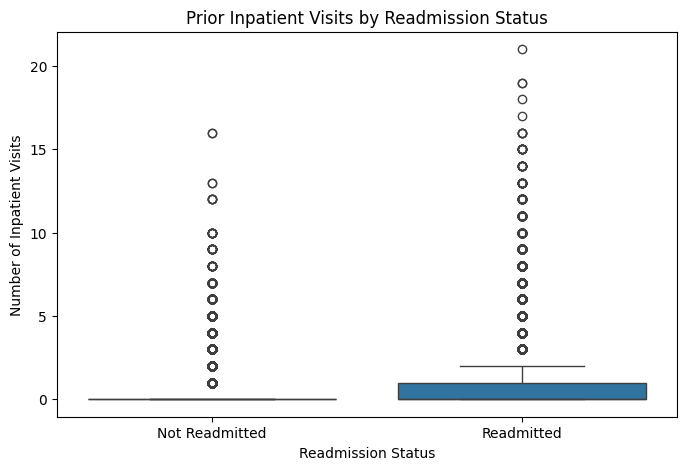

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="readmitted_binary", y="number_inpatient")
plt.title("Prior Inpatient Visits by Readmission Status")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Inpatient Visits")
plt.show()

## Insight 4: Prior inpatient use is a strong warning sign

Patients with more prior inpatient visits may represent a higher-risk population and may need more aggressive follow-up after discharge.

### Clinical question 5: Do lab tests tell a story?

In [8]:
a1c_counts = df["A1Cresult"].value_counts()
glu_counts = df["max_glu_serum"].value_counts()

a1c_counts, glu_counts

(A1Cresult
 Not Measured    84748
 >8               8216
 Norm             4990
 >7               3812
 Name: count, dtype: int64,
 max_glu_serum
 Not Measured    96420
 Norm             2597
 >200             1485
 >300             1264
 Name: count, dtype: int64)

## Insight 5: Many lab tests were not measured

Missing A1C and glucose serum results may reflect that the tests were not ordered, which can itself be clinically meaningful rather than simply missing data.

In [9]:
# Demographic notes

gender_table = pd.crosstab(df["gender"], df["readmitted_binary"], normalize="index") * 100
race_table = pd.crosstab(df["race"], df["readmitted_binary"], normalize="index") * 100

gender_table.round(2), race_table.round(2)

(readmitted_binary  Not Readmitted  Readmitted
 gender                                       
 Female                      53.08       46.92
 Male                        54.88       45.12
 Unknown/Invalid            100.00        0.00,
 readmitted_binary  Not Readmitted  Readmitted
 race                                         
 AfricanAmerican             54.25       45.75
 Asian                       64.74       35.26
 Caucasian                   53.07       46.93
 Hispanic                    58.08       41.92
 Other                       60.76       39.24
 unknown                     68.06       31.94)

## Demographic Interpretation

Demographic differences were explored, but the most actionable patterns appear to come from utilization and clinical complexity rather than demographic variables alone.

## High-Risk Clinical Profile

Based on the observed patterns, a higher-risk patient may be characterized by:

- higher prior inpatient utilization
- longer length of stay
- greater medication burden
- missing or unperformed lab measurements

## Clinical Recommendations

- Prioritize transitional care for patients with prior inpatient history.
- Consider closer post-discharge follow-up for patients with longer stays.
- Review medication burden as a possible marker of complexity.
- Investigate testing patterns for A1C and glucose-related labs.

## Limitations

- This analysis is observational and cannot prove causality.
- Some missing values may represent unperformed tests rather than true absence.
- Readmission was simplified into a binary outcome for insight generation.

## Conclusion

This project shows that readmission is linked more strongly to healthcare utilization and clinical complexity than to simple demographic patterns. The next step would be to build a predictive model or a lightweight risk scoring framework.